🚀 Sube tu archivo ARC_GOVERNOR_MASTER.csv socio...


Saving 1mes100bars_ARC_AUTO_SIGNALS.csv to 1mes100bars_ARC_AUTO_SIGNALS.csv
✅ Archivo cargado exitosamente (UTF-16).

💎 ESTADÍSTICAS DE FÍSICA FRACTAL
Total de registros: 13312
Señales puras tras limpieza: 4782
------------------------------

🔥 DISPAROS POR TIMEFRAME:
TRIGGER
M2     1888
M10    1280
H1     1228
H6      386
Name: count, dtype: int64


/tmp/ipython-input-1529683966.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0,1], data=df_clean, x='TRIGGER', y='E_RATIO', palette='magma', inner="quart")


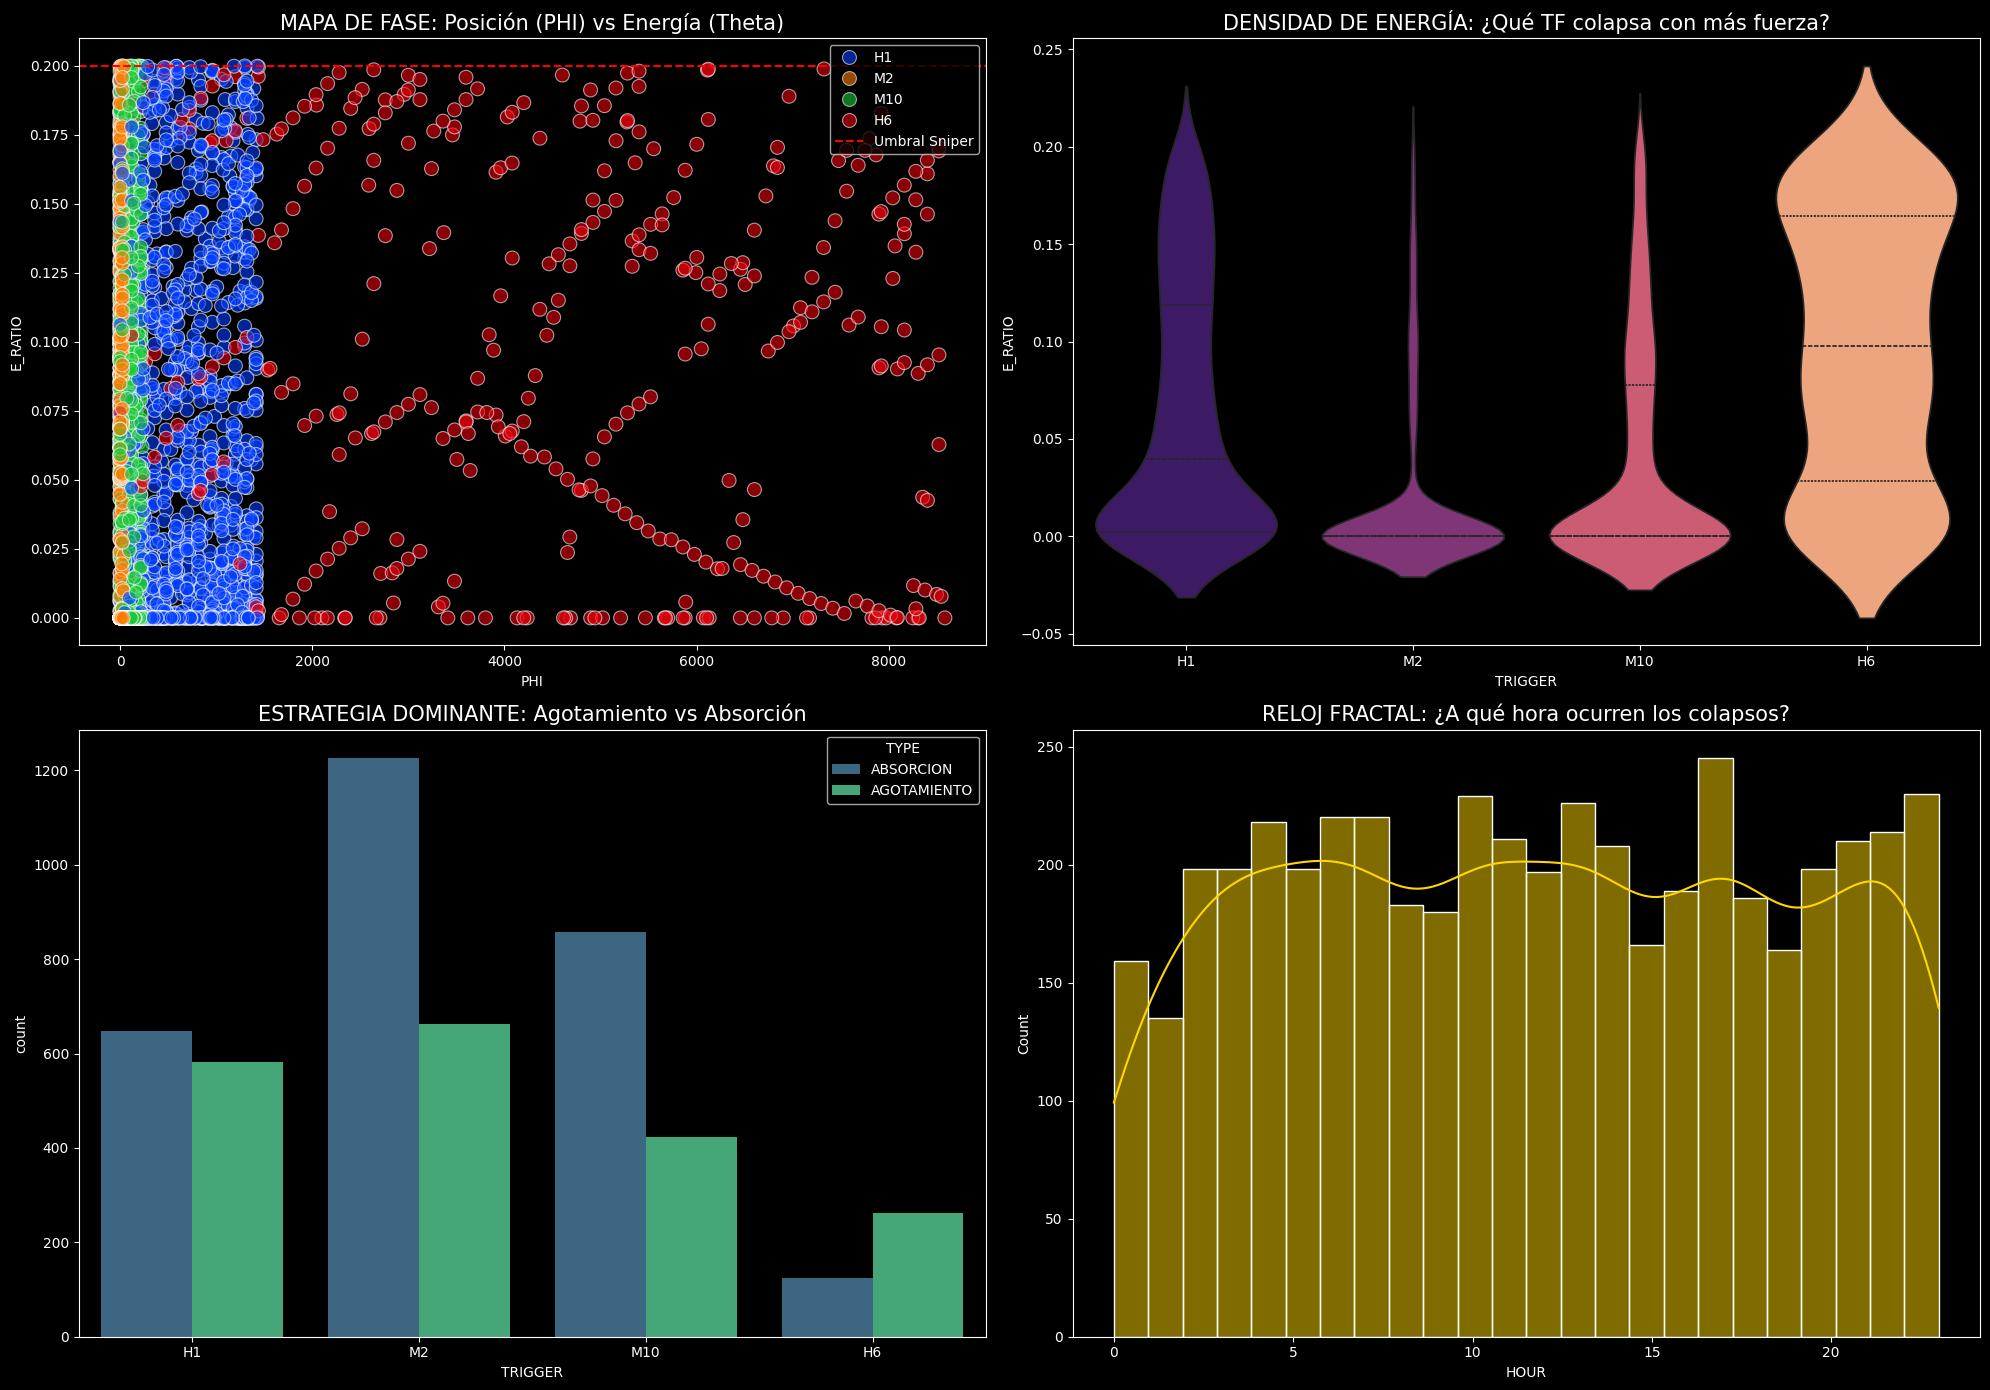


🎯 --- TOP 10 SEÑALES DE MÁXIMA COMPRESIÓN ($	heta$ Mínimo) ---
                    TIME TRIGGER         TYPE        PHI  E_RATIO        SL  \
1693 2026-01-13 05:48:00     M10    ABSORCION   194.8382      0.0  16097.02   
1702 2026-01-13 08:06:00      M2  AGOTAMIENTO     0.9584      0.0  16126.30   
1701 2026-01-13 07:58:00      M2    ABSORCION     5.0628      0.0  16104.46   
1700 2026-01-13 07:52:00      M2    ABSORCION    12.9005      0.0  16063.13   
1699 2026-01-13 07:43:00      M2    ABSORCION    40.1575      0.0  16054.65   
1698 2026-01-13 07:38:00      M2    ABSORCION     0.0142      0.0  16058.11   
1697 2026-01-13 07:37:00      H6    ABSORCION  2337.6382      0.0  15904.87   
1696 2026-01-13 07:29:00      H6    ABSORCION  2156.8382      0.0  15904.95   
1695 2026-01-13 07:14:00     M10    ABSORCION    96.8380      0.0  16035.83   
1694 2026-01-13 06:26:00      M2  AGOTAMIENTO    12.8301      0.0  16164.78   

           TP1       TP2  
1693  16186.84  16307.91  
1702  16088.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# 1. CARGA DE DATOS (PROTECCIÓN UTF-16)
print("🚀 Sube tu archivo ARC_GOVERNOR_MASTER.csv socio...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    # MT5 genera CSVs en UTF-16 por defecto
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-16', sep=',')
    print("✅ Archivo cargado exitosamente (UTF-16).")
except:
    # Fallback a UTF-8 por si acaso
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-8', sep=',')
    print("✅ Archivo cargado exitosamente (UTF-8).")

# --- LIMPIEZA Y PREPARACIÓN ---
df['TIME'] = pd.to_datetime(df['TIME'])
df = df.sort_values(by='TIME')

# Filtro de Ruido: Agrupamos señales cada 5 minutos y nos quedamos con el mejor (mínimo) Theta
df_clean = df.copy()
df_clean['G_TIME'] = df_clean['TIME'].dt.floor('5min')
df_clean = df_clean.sort_values('E_RATIO').groupby(['G_TIME', 'TRIGGER', 'TYPE']).first().reset_index()
df_clean = df_clean.sort_values('TIME')

# 2. RESUMEN DE MINERÍA
print("\n" + "="*40)
print("💎 ESTADÍSTICAS DE FÍSICA FRACTAL")
print("="*40)
print(f"Total de registros: {len(df)}")
print(f"Señales puras tras limpieza: {len(df_clean)}")
print("-" * 30)
print("\n🔥 DISPAROS POR TIMEFRAME:")
print(df_clean['TRIGGER'].value_counts())

# 3. VISUALIZACIÓN MAESTRA
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Gráfico 1: Mapa de Fase PHI vs THETA
# Aquí buscamos puntos con E_RATIO < 0.20
sns.scatterplot(ax=axes[0,0], data=df_clean, x='PHI', y='E_RATIO', hue='TRIGGER', s=100, palette='bright', alpha=0.6)
axes[0,0].axhline(0.20, color='red', linestyle='--', label='Umbral Sniper')
axes[0,0].set_title('MAPA DE FASE: Posición (PHI) vs Energía (Theta)', fontsize=15)
axes[0,0].legend()

# Gráfico 2: Densidad de Colapso (Violín)
sns.violinplot(ax=axes[0,1], data=df_clean, x='TRIGGER', y='E_RATIO', palette='magma', inner="quart")
axes[0,1].set_title('DENSIDAD DE ENERGÍA: ¿Qué TF colapsa con más fuerza?', fontsize=15)

# Gráfico 3: Frecuencia por Tipo
sns.countplot(ax=axes[1,0], data=df_clean, x='TRIGGER', hue='TYPE', palette='viridis')
axes[1,0].set_title('ESTRATEGIA DOMINANTE: Agotamiento vs Absorción', fontsize=15)

# Gráfico 4: Ventana Horaria de Actividad
df_clean['HOUR'] = df_clean['TIME'].dt.hour
sns.histplot(ax=axes[1,1], data=df_clean, x='HOUR', bins=24, kde=True, color='gold')
axes[1,1].set_title('RELOJ FRACTAL: ¿A qué hora ocurren los colapsos?', fontsize=15)

plt.tight_layout()
plt.show()

# 4. TABLA SNIPER (Top 10 señales de máxima compresión)
print("\n🎯 --- TOP 10 SEÑALES DE MÁXIMA COMPRESIÓN ($\theta$ Mínimo) ---")
sniper = df_clean.sort_values('E_RATIO').head(10)
print(sniper[['TIME', 'TRIGGER', 'TYPE', 'PHI', 'E_RATIO', 'SL', 'TP1', 'TP2']])